<div style="
background-color:#fff0f3;
padding:20px;
border-left:8px solid crimson;
border-radius:10px;
text-align:center;">

<h1 style="color:crimson;">
📊 E-Commerce Sales and Website Conversion Analysis Using Python
</h1>

<p style="font-size:18px; color:#555;">
Maven Fuzzy Factory Business Analytics Project
</p>

</div>

# Introduction

## Project Title
E-commerce Sales and Website Conversion Analysis Using Python

## Introduction

The rapid growth of e-commerce platforms has generated large volumes of customer, sales, and website interaction data. Analyzing this data helps businesses understand customer behavior, improve sales performance, optimize marketing strategies, and enhance overall business decision-making.

This project focuses on analyzing the Maven Fuzzy Factory e-commerce dataset using Python for data analytics and exploratory data analysis (EDA). The dataset contains information related to customer orders, products, website sessions, page views, and refunds.

The main objectives of this project are:
- Analyze sales performance
- Identify top-performing products
- Study customer website behavior
- Evaluate conversion rates
- Generate business insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')
sessions = pd.read_csv('website_sessions.csv')
pageviews = pd.read_csv('website_pageviews.csv')
refunds = pd.read_csv('order_item_refunds.csv')

In [3]:
orders.shape

(32313, 8)

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB


In [5]:
orders.head(10)

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
5,6,2012-03-20 16:12:47,232,232,1,1,49.99,19.49
6,7,2012-03-20 17:03:41,241,241,1,1,49.99,19.49
7,8,2012-03-20 23:35:27,295,295,1,1,49.99,19.49
8,9,2012-03-21 02:35:01,304,304,1,1,49.99,19.49
9,10,2012-03-21 06:45:58,317,317,1,1,49.99,19.49


In [6]:
orders.tail(10)

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
32303,32304,2015-03-19 00:37:21,472730,394207,3,2,75.98,23.98
32304,32305,2015-03-19 01:04:35,472740,377958,1,1,49.99,19.49
32305,32306,2015-03-19 01:42:17,472754,365383,4,1,29.99,9.49
32306,32307,2015-03-19 01:51:39,472755,394226,3,1,45.99,14.49
32307,32308,2015-03-19 02:11:42,472761,394231,1,1,49.99,19.49
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49
32312,32313,2015-03-19 05:38:31,472818,386000,1,1,49.99,19.49


In [7]:
orders.describe()

,order_id,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
count,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000
mean,16157.000000,258292.288707,215691.622629,1.392474,1.238666,59.991636,22.355406
std,9328.103961,132427.649842,108402.203189,0.732277,0.426274,17.808771,6.238621
min,1.000000,20.000000,13.000000,1.000000,1.000000,29.990000,9.490000
25%,8079.000000,144828.000000,124135.000000,1.000000,1.000000,49.990000,19.490000
50%,16157.000000,263554.000000,221461.000000,1.000000,1.000000,49.990000,19.490000
75%,24235.000000,374799.000000,310542.000000,2.000000,1.000000,59.990000,22.490000
max,32313.000000,472818.000000,394273.000000,4.000000,2.000000,109.980000,41.980000


In [9]:
order_items.shape

(40025, 7)

In [10]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.1+ MB


In [11]:
order_items.head(10)

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
5,6,2012-03-20 16:12:47,6,1,1,49.99,19.49
6,7,2012-03-20 17:03:41,7,1,1,49.99,19.49
7,8,2012-03-20 23:35:27,8,1,1,49.99,19.49
8,9,2012-03-21 02:35:01,9,1,1,49.99,19.49
9,10,2012-03-21 06:45:58,10,1,1,49.99,19.49


In [12]:
order_items.tail(10)

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
40015,40016,2015-03-19 01:04:35,32305,1,1,49.99,19.49
40016,40017,2015-03-19 01:42:17,32306,4,1,29.99,9.49
40017,40018,2015-03-19 01:51:39,32307,3,1,45.99,14.49
40018,40019,2015-03-19 02:11:42,32308,1,1,49.99,19.49
40019,40020,2015-03-19 03:58:12,32309,1,1,49.99,19.49
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49
40024,40025,2015-03-19 05:38:31,32313,1,1,49.99,19.49


In [13]:
order_items.describe()

,order_item_id,order_id,product_id,is_primary_item,price_usd,cogs_usd
count,40025.000000,40025.000000,40025.000000,40025.000000,40025.000000,40025.000000
mean,20013.000000,17121.957502,1.770019,0.807320,48.432473,18.047976
std,11554.366599,9053.765867,1.085561,0.394408,8.012370,3.856821
min,1.000000,1.000000,1.000000,0.000000,29.990000,9.490000
25%,10007.000000,9871.000000,1.000000,1.000000,49.990000,19.490000
50%,20013.000000,17490.000000,1.000000,1.000000,49.990000,19.490000
75%,30019.000000,24818.000000,2.000000,1.000000,49.990000,19.490000
max,40025.000000,32313.000000,4.000000,1.000000,59.990000,22.490000


In [15]:
products.shape


(4, 3)

In [16]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    4 non-null      int64 
 1   created_at    4 non-null      object
 2   product_name  4 non-null      object
dtypes: int64(1), object(2)
memory usage: 228.0+ bytes


In [18]:
products.head(10)

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [19]:
products.tail(10)

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [20]:
products.describe()

,product_id
count,4.000000
mean,2.500000
std,1.290994
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [21]:
sessions.shape

(472871, 9)

In [22]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   created_at          472871 non-null  object
 2   user_id             472871 non-null  int64 
 3   is_repeat_session   472871 non-null  int64 
 4   utm_source          389543 non-null  object
 5   utm_campaign        389543 non-null  object
 6   utm_content         389543 non-null  object
 7   device_type         472871 non-null  object
 8   http_referer        432954 non-null  object
dtypes: int64(3), object(6)
memory usage: 32.5+ MB


In [23]:
sessions.head(10)

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
5,6,2012-03-19 09:05:46,6,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
6,7,2012-03-19 09:06:27,7,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
7,8,2012-03-19 09:17:17,8,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
8,9,2012-03-19 09:27:56,9,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
9,10,2012-03-19 09:35:37,10,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [24]:
sessions.tail(10)

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
472861,472862,2015-03-19 07:39:21,394309,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
472862,472863,2015-03-19 07:40:25,394310,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
472863,472864,2015-03-19 07:41:11,394311,0,NaN,NaN,NaN,desktop,https://www.gsearch.com
472864,472865,2015-03-19 07:42:10,394312,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
472865,472866,2015-03-19 07:43:59,394313,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
472866,472867,2015-03-19 07:49:25,394314,0,gsearch,brand,g_ad_2,desktop,https://www.gsearch.com
472867,472868,2015-03-19 07:54:36,394315,0,bsearch,nonbrand,b_ad_1,mobile,https://www.bsearch.com
472868,472869,2015-03-19 07:55:40,394316,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
472869,472870,2015-03-19 07:56:29,394317,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
472870,472871,2015-03-19 07:59:08,394318,0,NaN,NaN,NaN,mobile,NaN


In [4]:
sessions.describe()

,website_session_id,user_id,is_repeat_session
count,472871.000000,472871.000000,472871.000000
mean,236436.000000,198037.970163,0.166119
std,136506.243908,111992.997798,0.372188
min,1.000000,1.000000,0.000000
25%,118218.500000,101966.500000,0.000000
50%,236436.000000,199483.000000,0.000000
75%,354653.500000,294433.000000,0.000000
max,472871.000000,394318.000000,1.000000


In [5]:
pageviews.shape

(1188124, 4)

In [6]:
pageviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   website_pageview_id  1188124 non-null  int64 
 1   created_at           1188124 non-null  object
 2   website_session_id   1188124 non-null  int64 
 3   pageview_url         1188124 non-null  object
dtypes: int64(2), object(2)
memory usage: 36.3+ MB


In [7]:
pageviews.head(10)

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home
5,6,2012-03-19 09:05:46,6,/home
6,7,2012-03-19 09:06:27,7,/home
7,8,2012-03-19 09:10:08,6,/products
8,9,2012-03-19 09:10:52,6,/the-original-mr-fuzzy
9,10,2012-03-19 09:14:02,6,/cart


In [8]:
pageviews.tail(10)

,website_pageview_id,created_at,website_session_id,pageview_url
1188114,1188115,2015-03-19 07:55:03,472866,/cart
1188115,1188116,2015-03-19 07:55:40,472869,/lander-3
1188116,1188117,2015-03-19 07:55:57,472868,/products
1188117,1188118,2015-03-19 07:56:29,472870,/lander-5
1188118,1188119,2015-03-19 07:57:22,472870,/products
1188119,1188120,2015-03-19 07:57:32,472866,/shipping
1188120,1188121,2015-03-19 07:58:13,472870,/the-original-mr-fuzzy
1188121,1188122,2015-03-19 07:59:07,472866,/billing-2
1188122,1188123,2015-03-19 07:59:08,472871,/home
1188123,1188124,2015-03-19 07:59:32,472868,/the-original-mr-fuzzy


In [9]:
pageviews.describe()

,website_pageview_id,website_session_id
count,1.188124e+06,1.188124e+06
mean,5.940625e+05,2.444585e+05
std,3.429820e+05,1.356199e+05
min,1.000000e+00,1.000000e+00
25%,2.970318e+05,1.277860e+05
50%,5.940625e+05,2.478080e+05
75%,8.910932e+05,3.627390e+05
max,1.188124e+06,4.728710e+05


In [10]:
refunds.shape

(1731, 5)

In [11]:
refunds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_item_refund_id  1731 non-null   int64  
 1   created_at            1731 non-null   object 
 2   order_item_id         1731 non-null   int64  
 3   order_id              1731 non-null   int64  
 4   refund_amount_usd     1731 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 67.7+ KB


In [12]:
refunds.head(10)

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
5,6,2012-05-04 11:59:07,147,147,49.99
6,7,2012-05-12 02:41:14,186,186,49.99
7,8,2012-05-16 13:06:01,191,191,49.99
8,9,2012-05-24 16:00:09,179,179,49.99
9,10,2012-05-30 17:20:44,199,199,49.99


In [13]:
refunds.tail(10)

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
1721,1722,2015-03-27 10:10:53,39860,32191,49.99
1722,1723,2015-03-27 12:16:02,39674,32051,45.99
1723,1724,2015-03-28 05:34:49,39819,32156,45.99
1724,1725,2015-03-28 08:38:31,39449,31884,49.99
1725,1726,2015-03-29 23:41:36,39759,32111,49.99
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99
1730,1731,2015-04-01 18:11:08,39947,32252,45.99


# Find missing values

In [15]:
orders.isnull().sum()

order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
dtype: int64

In [16]:
order_items.isnull().sum()

order_item_id      0
created_at         0
order_id           0
product_id         0
is_primary_item    0
price_usd          0
cogs_usd           0
dtype: int64

In [17]:
products.isnull().sum()

product_id      0
created_at      0
product_name    0
dtype: int64

In [18]:
sessions.isnull().sum()

website_session_id        0
created_at                0
user_id                   0
is_repeat_session         0
utm_source            83328
utm_campaign          83328
utm_content           83328
device_type               0
http_referer          39917
dtype: int64

In [19]:
pageviews.isnull().sum()

website_pageview_id    0
created_at             0
website_session_id     0
pageview_url           0
dtype: int64

In [20]:
refunds.isnull().sum()

order_item_refund_id    0
created_at              0
order_item_id           0
order_id                0
refund_amount_usd       0
dtype: int64

## Handling Missing Values

Some columns in the dataset contained missing values, especially in marketing-related fields such as utm_source, utm_campaign, utm_content, and http_referer. 

Instead of removing rows, the missing values were replaced with meaningful labels such as 'Direct', 'No Campaign', and 'No Referrer' to preserve the dataset and improve analysis.

In [3]:
sessions['utm_source'] = sessions['utm_source'].fillna('Direct')
sessions['utm_campaign'] = sessions['utm_campaign'].fillna('No Campaign')
sessions['utm_content'] = sessions['utm_content'].fillna('No Content')
sessions['http_referer'] = sessions['http_referer'].fillna('No Referrer')

In [4]:
sessions.isnull().sum()

website_session_id    0
created_at            0
user_id               0
is_repeat_session     0
utm_source            0
utm_campaign          0
utm_content           0
device_type           0
http_referer          0
dtype: int64

# Finding out is there any duplicates

In [4]:
orders.duplicated().sum()

np.int64(0)

In [5]:
order_items.duplicated().sum()

np.int64(0)

In [6]:
products.duplicated().sum()

np.int64(0)

In [7]:
sessions.duplicated().sum()

np.int64(0)

In [8]:
pageviews.duplicated().sum()


np.int64(0)

In [9]:
refunds.duplicated().sum()

np.int64(0)

## Handling Date Columns

Several tables in the dataset contain a `created_at` column, which stores the date and time of different activities such as website visits, orders, product purchases, and refunds.

To perform time-based analysis such as monthly sales trends, yearly growth, and customer activity analysis, the `created_at` columns were converted into proper datetime format using Pandas.

The following tables contain date-related columns:

| Table Name | Date Column | Purpose |
|---|---|---|
| orders | created_at | Order date and time |
| order_items | created_at | Product purchase date |
| products | created_at | Product added date |
| website_sessions | created_at | Website session start time |
| website_pageviews | created_at | Page viewing time |
| order_item_refunds | created_at | Refund date and time |

The datetime conversion was performed using the following Python code.

In [4]:
orders['created_at'] = pd.to_datetime(orders['created_at'])

In [5]:
order_items['created_at'] = pd.to_datetime(order_items['created_at'])

In [6]:
products['created_at'] = pd.to_datetime(products['created_at'])


In [7]:
sessions['created_at'] = pd.to_datetime(sessions['created_at'])

In [8]:
pageviews['created_at'] = pd.to_datetime(pageviews['created_at'])


In [9]:
refunds['created_at'] = pd.to_datetime(refunds['created_at'])

# Additional derived column
Additional date-related columns such as year, month, and day were extracted from the `created_at` column to support trend and seasonality analysis.

In [10]:
orders['year'] = orders['created_at'].dt.year


In [11]:
orders['month'] = orders['created_at'].dt.month


In [12]:
orders['day'] = orders['created_at'].dt.day

In [14]:
orders.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,year,month,day
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012,3,19
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012,3,19
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012,3,20
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012,3,20
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012,3,20


In [14]:
orders.tail()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,year,month,day
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,2015,3,19
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,2015,3,19
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2015,3,19
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,2015,3,19
32312,32313,2015-03-19 05:38:31,472818,386000,1,1,49.99,19.49,2015,3,19


# ## Dataset Merging

Different tables in the dataset were merged using common columns such as `order_id`, `product_id`, and `website_session_id`.

Merging datasets helps combine related business information from multiple tables into a single dataframe for deeper analysis.

For example:
- `orders` and `order_items` were merged using `order_id`
- Product information was added using `product_id`

This enabled comprehensive analysis of sales, products, revenue, and customer behavior.

In [13]:
# 1. Merge orders + order_items
merged_orders = pd.merge(orders, order_items, on='order_id')

In [14]:
# 2. Merge with products table
sales_data = pd.merge(merged_orders, products, on='product_id')

In [15]:
# 3. Merge refunds

refund_data = pd.merge(
    order_items,
    refunds,
    on='order_item_id'
)

refund_data = pd.merge(
    refund_data,
    products,
    on='product_id'
)


In [16]:
# 4. Merge website sessions + orders
session_orders = pd.merge(sessions, orders, on='website_session_id')

In [17]:
# 5. Merge website sessions + pageviews
session_pageviews = pd.merge(sessions, pageviews, on='website_session_id')

In [18]:
# Sales Data (Comprehensive from merged column)
merged1 = pd.merge(orders, order_items, on='order_id')

sales_data = pd.merge(merged1, products, on='product_id')

In [19]:
sales_data = pd.merge(
    sales_data,
    sessions[['website_session_id', 'utm_source']],
    on='website_session_id',
    how='left'
)

In [22]:
sales_data.head()

,order_id,created_at_x,website_session_id,user_id,primary_product_id,items_purchased,price_usd_x,cogs_usd_x,year,month,day,order_item_id,created_at_y,product_id,is_primary_item,price_usd_y,cogs_usd_y,created_at,product_name,utm_source
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012,3,19,1,2012-03-19 10:42:46,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012,3,19,2,2012-03-19 19:27:37,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012,3,20,3,2012-03-20 06:44:45,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012,3,20,4,2012-03-20 09:41:45,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012,3,20,5,2012-03-20 11:28:15,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch


# Rename columns clearly.
## Handling Duplicate Columns After Merging

After merging datasets, some columns appeared with suffixes such as `_x` and `_y`. 

These suffixes were automatically added by Pandas because multiple tables contained columns with the same names, such as `created_at`, `price_usd`, and `cogs_usd`.

To improve readability and analysis, the columns were renamed appropriately and unnecessary duplicate columns were removed where required.

In [20]:
sales_data = sales_data.rename(columns={
    'created_at_x': 'order_date',
    'created_at_y': 'item_date',
    'price_usd_x': 'order_price',
    'price_usd_y': 'item_price',
    'cogs_usd_x': 'order_cogs',
    'cogs_usd_y': 'item_cogs'
})

In [24]:
sales_data.head()

,order_id,order_date,website_session_id,user_id,primary_product_id,items_purchased,order_price,order_cogs,year,month,day,order_item_id,item_date,product_id,is_primary_item,item_price,item_cogs,created_at,product_name,utm_source
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012,3,19,1,2012-03-19 10:42:46,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012,3,19,2,2012-03-19 19:27:37,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012,3,20,3,2012-03-20 06:44:45,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012,3,20,4,2012-03-20 09:41:45,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012,3,20,5,2012-03-20 11:28:15,1,1,49.99,19.49,2012-03-19 08:00:00,The Original Mr. Fuzzy,gsearch


# Exploratory Data Analysis

In [21]:
sales_data.groupby('product_name')['item_price'].sum().sort_values(ascending=False)

product_name
The Original Mr. Fuzzy        1211057.74
The Forever Love Bear          347702.04
The Birthday Sugar Panda       229260.15
The Hudson River Mini bear     150489.82
Name: item_price, dtype: float64

# ## Revenue Analysis by Product

The dataset was grouped by product name to calculate the total revenue generated by each product.

This analysis helps identify:
- highest revenue-generating products
- product performance
- customer purchasing trends

 ## Monthly Orders Analysis by Product

A pivot table was created to analyze monthly order counts for each product.

The pivot table helps compare:
- product demand across months
- seasonal purchasing patterns
- monthly product performance

Months were used as rows, product names as columns, and total order counts as values.

In [22]:
pivot_table = sales_data.pivot_table(
    values='order_id',
    index='month',
    columns='product_name',
    aggfunc='count',
    fill_value=0
)

pivot_table

product_name,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
month,,,,
1,650,624,610,2463
2,616,1157,746,2033
3,507,481,548,2029
4,267,308,259,1475
5,299,328,298,1627
6,288,335,249,1536
7,276,339,264,1639
8,294,335,303,1696
9,317,349,327,1880


# Best selling Product

This E-commerce website selling 4 types of teddy bear from this finding out best selling product for each year, for group by sales data on the basis of year and count.

In [23]:
best_selling = sales_data.groupby(
    ['year', 'product_name']
)['order_item_id'].count().reset_index(name='total_sales')

Get Highest Selling Product in Each Year

In [24]:
best_selling_each_year = best_selling.loc[
    best_selling.groupby('year')['total_sales'].idxmax()
]

best_selling_each_year

,year,product_name,total_sales
0,2012,The Original Mr. Fuzzy,2586
3,2013,The Original Mr. Fuzzy,6151
7,2014,The Original Mr. Fuzzy,12120
11,2015,The Original Mr. Fuzzy,3369


Refund Analysis of products

In [25]:
#1. Total Refund Amount
refund_data['refund_amount_usd'].sum()

np.float64(85338.69)

In [26]:
#2. Most Refunded Products
refund_data.groupby('product_name')[
    'refund_amount_usd'
].sum().sort_values(ascending=False)

product_name
The Original Mr. Fuzzy        61837.63
The Birthday Sugar Panda      13842.99
The Forever Love Bear          7738.71
The Hudson River Mini bear     1919.36
Name: refund_amount_usd, dtype: float64

In [27]:
#3. Refund Count by Product
refund_data.groupby('product_name')[
    'order_item_refund_id'
].count().sort_values(ascending=False)

product_name
The Original Mr. Fuzzy        1237
The Birthday Sugar Panda       301
The Forever Love Bear          129
The Hudson River Mini bear      64
Name: order_item_refund_id, dtype: int64

In [28]:
#4. Refund Trend by Year
refund_data['created_at_y'] = pd.to_datetime(
    refund_data['created_at_y']
)

refund_data['year'] = refund_data['created_at_y'].dt.year

In [29]:
refund_data.groupby('year')[
    'refund_amount_usd'
].sum()

year
2012     8448.31
2013    17202.61
2014    46952.40
2015    12735.37
Name: refund_amount_usd, dtype: float64

# Comparison of purchased product and Refunded product

In [30]:
purchase_count = sales_data.groupby('product_name')[
    'order_item_id'
].count()

refund_count = refund_data.groupby('product_name')[
    'order_item_refund_id'
].count()

comparison = pd.concat(
    [purchase_count, refund_count],
    axis=1
)

comparison.columns = [
    'total_purchases',
    'total_refunds'
]

comparison = comparison.fillna(0)

comparison

,total_purchases,total_refunds
product_name,,
The Birthday Sugar Panda,4985,301
The Forever Love Bear,5796,129
The Hudson River Mini bear,5018,64
The Original Mr. Fuzzy,24226,1237


# Website Traffic Analysis

Website traffic analysis was performed to understand visitor behavior and website performance.

The analysis focused on:
- traffic sources
- device usage
- session trends
- repeat visitors
- website activity patterns

This helps evaluate marketing effectiveness and customer engagement on the e-commerce platform.

In [31]:
#1. Total Website Sessions
sessions['website_session_id'].nunique()

472871

In [32]:
#2. Traffic Source Analysis
sessions['utm_source'].value_counts()

utm_source
gsearch       316035
Direct         83328
bsearch        62823
socialbook     10685
Name: count, dtype: int64

In [33]:
#Traffic Source Percentage
sessions['utm_source'].value_counts(normalize=True) * 100

utm_source
gsearch       66.833238
Direct        17.621719
bsearch       13.285441
socialbook     2.259601
Name: proportion, dtype: float64

In [34]:
# 3. Device Type Analysis
sessions['device_type'].value_counts()

device_type
desktop    327027
mobile     145844
Name: count, dtype: int64

In [35]:
#Device Type Percentage
sessions['device_type'].value_counts(normalize=True) * 100

device_type
desktop    69.157762
mobile     30.842238
Name: proportion, dtype: float64

In [36]:
# 4. Repeat Visitor Analysis
sessions['is_repeat_session'].value_counts()

is_repeat_session
0    394318
1     78553
Name: count, dtype: int64

In [37]:
# Percentage of Repeat Visitors
repeat_percentage = (
    sessions['is_repeat_session'].sum()
    /
    len(sessions)
) * 100

print(repeat_percentage)

16.6119301035589


In [38]:
#5. Top Referral Websites
sessions['http_referer'].value_counts().head(10)

http_referer
https://www.gsearch.com       351237
https://www.bsearch.com        71032
No Referrer                    39917
https://www.socialbook.com     10685
Name: count, dtype: int64

In [39]:
## 6. Website Traffic by Year
#Create Year Column
sessions['year'] = sessions['created_at'].dt.year
#Traffic Trend
sessions.groupby('year')[
    'website_session_id'
].count()

year
2012     62470
2013    112781
2014    233422
2015     64198
Name: website_session_id, dtype: int64

In [40]:
## 7 Monthly Traffic for Each Site
#  Create Month Column
sessions['created_at'] = pd.to_datetime(
    sessions['created_at']
)

sessions['month'] = sessions['created_at'].dt.month

In [41]:
# Pivot Table
site_traffic = sessions.pivot_table(
    values='website_session_id',
    index='month',
    columns='http_referer',
    aggfunc='count',
    fill_value=0
)

site_traffic

http_referer,No Referrer,https://www.bsearch.com,https://www.gsearch.com,https://www.socialbook.com
month,,,,
1,4801,7023,33121,1618
2,4405,7054,33535,2237
3,3473,5425,28757,1240
4,2200,3978,22880,0
5,2390,4236,23620,0
6,2393,4158,23452,0
7,2725,4365,25100,0
8,2777,4895,25775,420
9,2936,5845,26011,847


In [42]:
# 8 Website Sessions by Campaign
sessions['utm_campaign'].value_counts()

utm_campaign
nonbrand            337615
No Campaign          83328
brand                41243
desktop_targeted      5590
pilot                 5095
Name: count, dtype: int64

VISUALIZATIONS

1. Monthly Revenue Trend
Objective

Analyze how revenue changes over time.

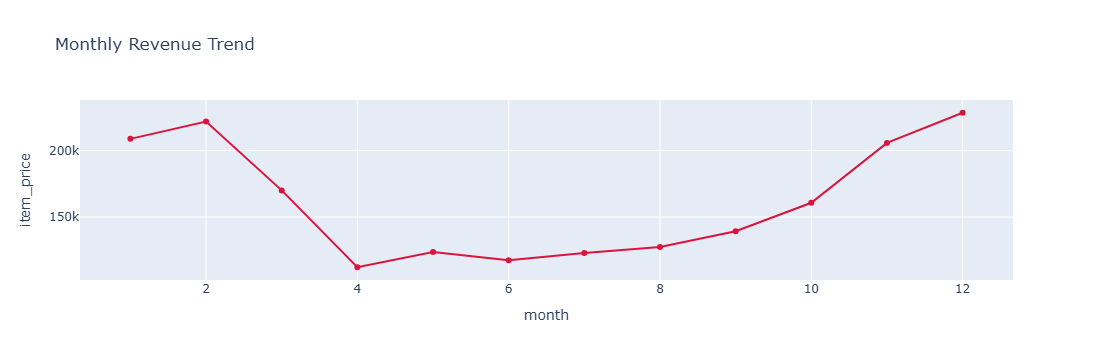

In [43]:
import plotly.express as px

monthly_revenue = sales_data.groupby('month')['item_price'].sum().reset_index()

fig = px.line(
    monthly_revenue,
    x='month',
    y='item_price',
    title='Monthly Revenue Trend',
    markers=True,
    color_discrete_sequence=['crimson']
)

fig.show()

### Key Insight

Revenue experienced a major decline between February and April, falling by nearly 50%. However, a strong recovery began in the second half of the year, with revenue more than doubling from April to December. The highest revenue was recorded in December, indicating strong year-end demand and the potential impact of seasonal shopping behavior.

2. Revenue by Product

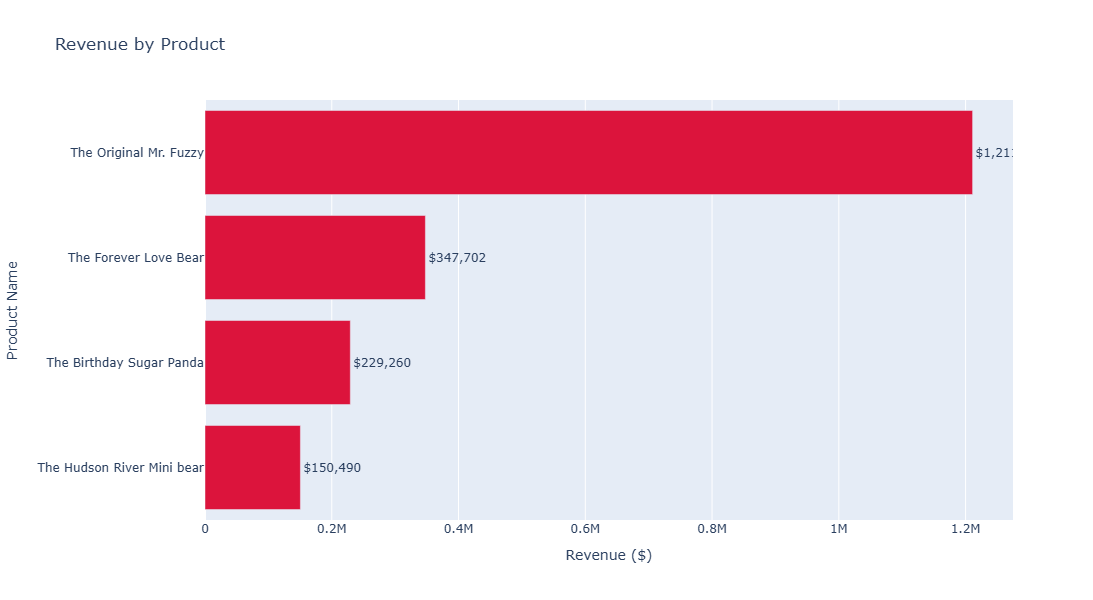

In [53]:
import plotly.express as px

revenue_by_product = (
    sales_data.groupby('product_name')['item_price']
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)

fig = px.bar(
    revenue_by_product,
    x='item_price',
    y='product_name',
    orientation='h',
    title='Revenue by Product',
    text='item_price',
    color_discrete_sequence=['crimson']
)

fig.update_traces(
    texttemplate='$%{x:,.0f}',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Revenue ($)',
    yaxis_title='Product Name',
    height=600
)

fig.show()

### Insight

The highest revenue was generated by "The original Mr Fuzzy", while "The Hudson River MiniBear" contributed the least revenue.

"The Orginal MrFuzzy" generated approximately $1211057, which was 110.77% higher than the next best-performing product.

Higher revenue may be driven by stronger customer demand, better product positioning, higher repeat purchases, or successful marketing campaigns.

Focus inventory and promotional efforts on top-performing products while investigating opportunities to improve sales of lower-performing products.

3. Website Traffic Source Distribution

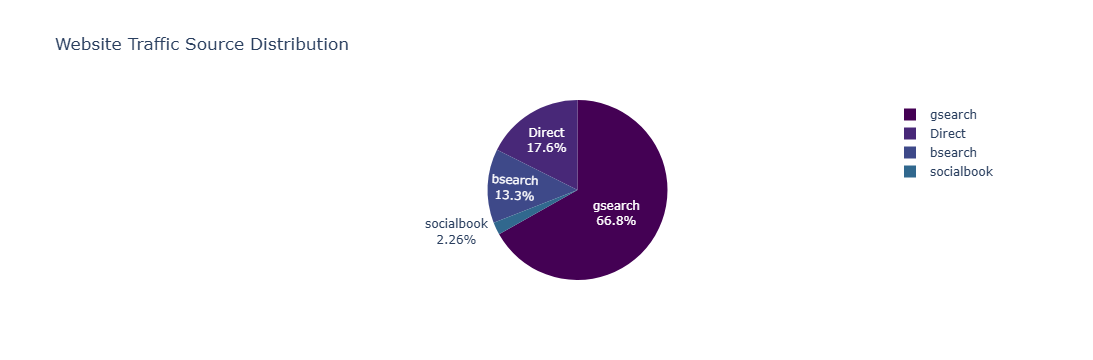

In [54]:
import plotly.express as px

traffic_source = (
    sessions['utm_source']
    .value_counts()
    .reset_index()
)

traffic_source.columns = ['Source', 'Sessions']

fig = px.pie(
    traffic_source,
    values='Sessions',
    names='Source',
    title='Website Traffic Source Distribution',
    color_discrete_sequence=px.colors.sequential.Viridis
)

fig.update_traces(
    textinfo='percent+label'
)

fig.show()

### Insight

The majority of website traffic originated from Google search, while social media contributed the smallest share.

Google search accounted for approximately 66.8% of total website sessions, indicating strong dominance among traffic acquisition channels.

The high contribution from this source suggests effective marketing campaigns, stronger brand visibility, or higher customer engagement through that channel.

**Business Recommendation**
Continue optimizing high-performing channels while investing in lower-performing sources to diversify traffic acquisition and reduce dependency on a single channel.

4. Monthly Orders by Product

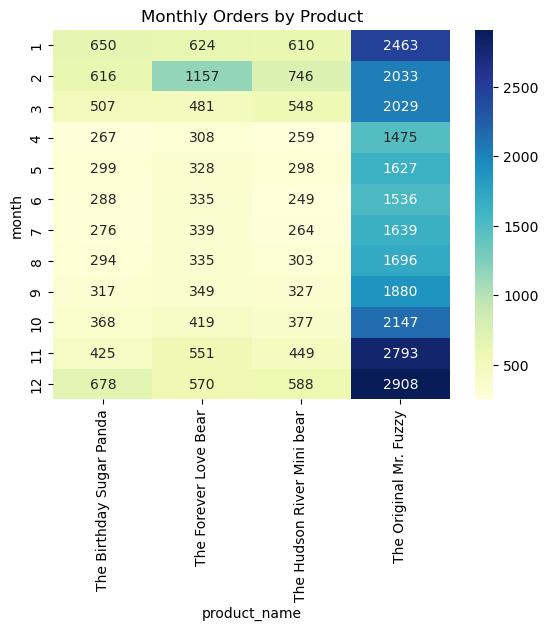

In [55]:
pivot_table = sales_data.pivot_table(
    values='order_id',
    index='month',
    columns='product_name',
    aggfunc='count',
    fill_value=0
)

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Monthly Orders by Product')
plt.show()

### Insight

The Original Mr. Fuzzy was the best-selling product throughout the year, consistently recording significantly higher order volumes than all other products. Sales peaked in December at approximately 2,900 orders, indicating strong year-end demand.

The Forever Love Bear experienced a notable sales spike in February, suggesting seasonal demand associated with gift-giving occasions. Most products showed increased sales during November and December, reflecting holiday-season purchasing behavior.

### Business Interpretation

The Original Mr. Fuzzy serves as the company's flagship product and primary sales driver. The strong increase in sales during the final quarter highlights the importance of seasonal demand and promotional activities.

### Recommendation

The company should prioritize inventory planning for Original Mr. Fuzzy before peak shopping periods and leverage seasonal marketing campaigns to maximize revenue. Products with lower sales volumes may benefit from targeted promotions and bundle offerings to improve performance.

5. Refund Analysis by Product

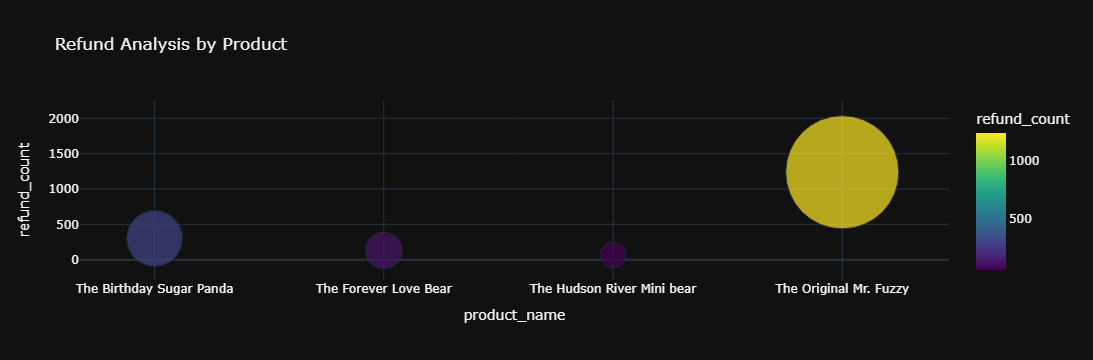

In [56]:
import plotly.express as px

refund_product = (
    refund_data.groupby('product_name')['order_item_refund_id']
    .count()
    .reset_index(name='refund_count')
)

fig = px.scatter(
    refund_product,
    x='product_name',
    y='refund_count',
    size='refund_count',
    color='refund_count',
    color_continuous_scale='Viridis',
    size_max=80,
    title='Refund Analysis by Product'
)

fig.update_layout(template='plotly_dark')

fig.show()

### Insight

The highest number of refunds was recorded for "The Original Mr.Fuzzy", while "The Hudson River Mini bear" had the lowest refund volume.

 "The Original Mr Fuzzy" accounted for approximately 71.46% of total refunds, significantly exceeding other products.

High refund rates may indicate product quality issues, customer expectation mismatches, shipping damage, or inaccurate product descriptions.

### Business Recommendation

- Investigate customer complaints for highly refunded products.
- Review product quality and packaging processes.
- Update product descriptions and images to better align customer expectations.
- Monitor refund trends regularly to identify recurring issues.

6.Best Selling Product by Month

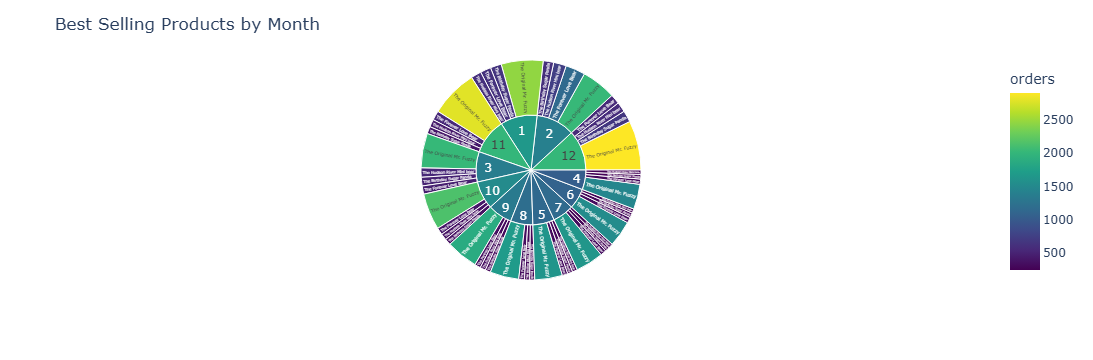

In [57]:


monthly_product = (
    sales_data.groupby(['month', 'product_name'])
    .size()
    .reset_index(name='orders')
)

fig = px.sunburst(
    monthly_product,
    path=['month', 'product_name'],
    values='orders',
    color='orders',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    title='Best Selling Products by Month'
)

fig.show()

### Key Insight

Original Mr. Fuzzy dominated product sales throughout the year and experienced substantial growth during the holiday season. November and December represented the strongest sales periods, highlighting the importance of seasonal demand and inventory planning. The company should leverage the popularity of its flagship product while developing strategies to improve the performance of other product lines.

7 Calculate Conversion Rate by Traffic Source

In [51]:
# Total sessions by source
source_sessions = (
    sessions.groupby('utm_source')['website_session_id']
    .nunique()
    .reset_index(name='total_sessions')
)

In [52]:
# Order by source
source_orders = (
    sales_data.groupby('utm_source')['order_id']
    .nunique()
    .reset_index(name='total_orders')
)

In [53]:
conversion_data = pd.merge(
    source_sessions,
    source_orders,
    on='utm_source',
    how='left'
)

conversion_data

,utm_source,total_sessions,total_orders
0,Direct,83328,6118
1,bsearch,62823,4519
2,gsearch,316035,21333
3,socialbook,10685,343


In [54]:
#Calculate conversion rate
conversion_data['conversion_rate'] = (
    conversion_data['total_orders']
    / conversion_data['total_sessions']
) * 100

conversion_data.sort_values(
    'conversion_rate',
    ascending=False
)

,utm_source,total_sessions,total_orders,conversion_rate
0,Direct,83328,6118,7.342070
1,bsearch,62823,4519,7.193225
2,gsearch,316035,21333,6.750202
3,socialbook,10685,343,3.210108


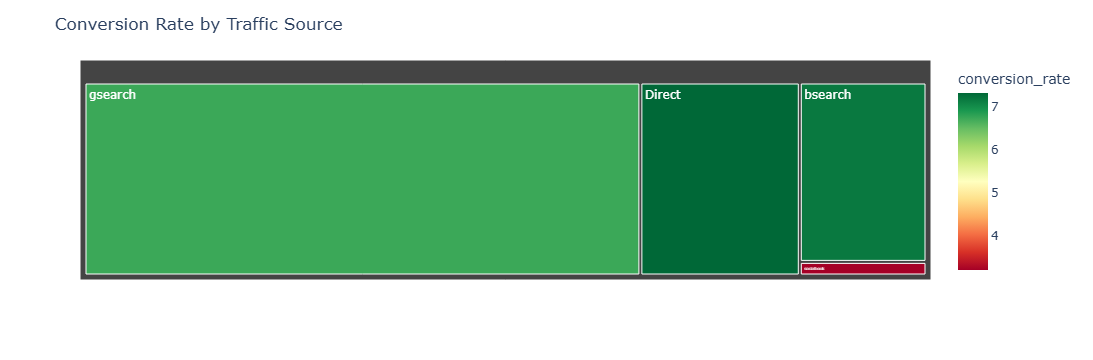

In [55]:
import plotly.express as px

fig = px.treemap(
    conversion_data,
    path=['utm_source'],
    values='total_orders',
    color='conversion_rate',
    color_continuous_scale='RdYlGn',
    hover_data=['total_sessions', 'total_orders', 'conversion_rate']
)

fig.update_layout(
    title='Conversion Rate by Traffic Source'
)

fig.show()

### Conversion Rate Analysis


Traffic sources showed varying conversion performance. Some channels generated a large volume of sessions but relatively few orders, while others converted visitors more effectively.

The highest-converting traffic source achieved a conversion rate of 7.34%, significantly outperforming the lowest-converting source at 3.2%.

High-converting channels may attract more targeted visitors who already have purchase intent, while low-converting channels may bring broader awareness traffic.

### Business Recommendation

- Increase investment in high-converting traffic sources.
- Review landing pages and campaign targeting for low-converting channels.
- Use successful channels as benchmarks for future marketing campaigns.

# 8 Conversion rate by product

In [101]:
# order by product
product_orders = (
    sales_data.groupby('product_name')['order_id']
    .nunique()
    .reset_index(name='orders')
)

product_orders

,product_name,orders
0,The Birthday Sugar Panda,4985
1,The Forever Love Bear,5796
2,The Hudson River Mini bear,5018
3,The Original Mr. Fuzzy,24226


In [102]:
# total website session
total_sessions = sessions['website_session_id'].nunique()

print(total_sessions)



472871


In [104]:
# Calculate conversion rate and sort into highest to lowest
product_orders['conversion_rate'] = (
    product_orders['orders']
    / total_sessions
) * 100
product_orders = product_orders.sort_values(
    'conversion_rate',
    ascending=False
)
product_orders

,product_name,orders,conversion_rate
3,The Original Mr. Fuzzy,24226,5.123173
1,The Forever Love Bear,5796,1.225704
2,The Hudson River Mini bear,5018,1.061177
0,The Birthday Sugar Panda,4985,1.054199


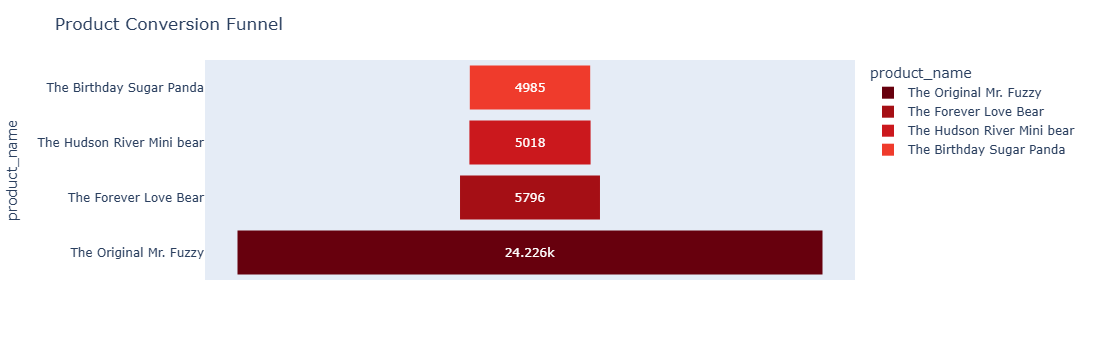

In [107]:
product_funnel = (
    sales_data.groupby('product_name')['order_id']
    .nunique()
    .reset_index(name='orders')
    .sort_values('orders', ascending=False)
)

fig = px.funnel(
    product_funnel,
    x='orders',
    y='product_name',
    color='product_name',
    color_discrete_sequence=px.colors.sequential.Reds_r
)

fig.update_layout(
    title='Product Conversion Funnel'
)

fig.show()

### Key Insight

Original Mr. Fuzzy dominated product conversions with 24,226 orders, generating over four times the sales of any other product. This indicates strong customer preference and establishes it as the company's flagship product. While this drives revenue growth, the business should promote other products to reduce dependence on a single product and create a more balanced sales portfolio.

9. New vs Repeat Visitors

In [56]:
visitor_type = (
    sessions['is_repeat_session']
    .value_counts()
    .reset_index()
)

visitor_type.columns = ['Visitor Type', 'Count']

visitor_type['Visitor Type'] = visitor_type['Visitor Type'].replace({
    0: 'New Visitor',
    1: 'Repeat Visitor'
})

In [57]:
visitor_type

,Visitor Type,Count
0,New Visitor,394318
1,Repeat Visitor,78553


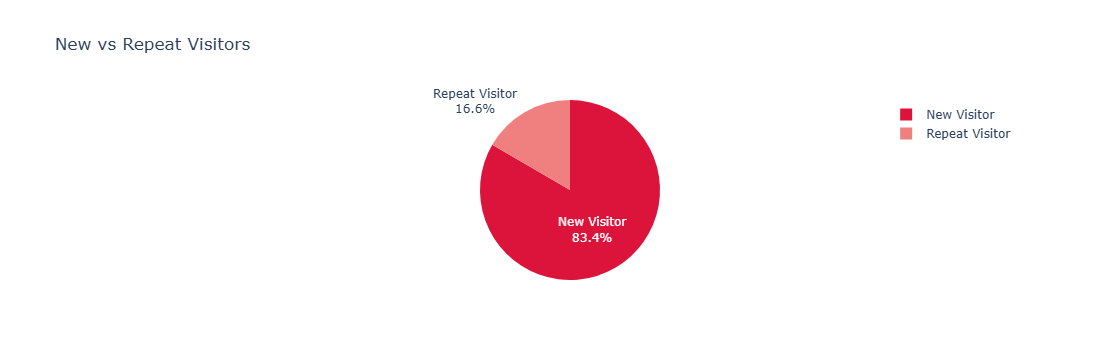

In [58]:
import plotly.express as px

fig = px.pie(
    visitor_type,
    names='Visitor Type',
    values='Count',
    title='New vs Repeat Visitors',
    color='Visitor Type',
    color_discrete_sequence=['crimson', 'lightcoral']
)

fig.update_traces(
    textinfo='percent+label'
)

fig.show()

## Insight

83.4% of website traffic comes from new visitors, indicating strong customer acquisition performance. However, repeat visitors represent only 16.6% of total traffic, suggesting opportunities to strengthen customer retention and increase customer lifetime value through loyalty and re-engagement strategies.

10. Correlation Heatmap 

In [60]:
# Selecting numeric columns
numeric_cols = sales_data.select_dtypes(include=['int64', 'float64'])

numeric_cols.head()

,order_id,website_session_id,user_id,primary_product_id,items_purchased,order_price,order_cogs,order_item_id,product_id,is_primary_item,item_price,item_cogs
0,1,20,20,1,1,49.99,19.49,1,1,1,49.99,19.49
1,2,104,104,1,1,49.99,19.49,2,1,1,49.99,19.49
2,3,147,147,1,1,49.99,19.49,3,1,1,49.99,19.49
3,4,160,160,1,1,49.99,19.49,4,1,1,49.99,19.49
4,5,177,177,1,1,49.99,19.49,5,1,1,49.99,19.49


In [69]:
corr_cols = [
    'items_purchased',
    'order_price',
    'order_cogs',
    'item_price',
    'item_cogs'
]

corr_matrix = sales_data[corr_cols].corr()

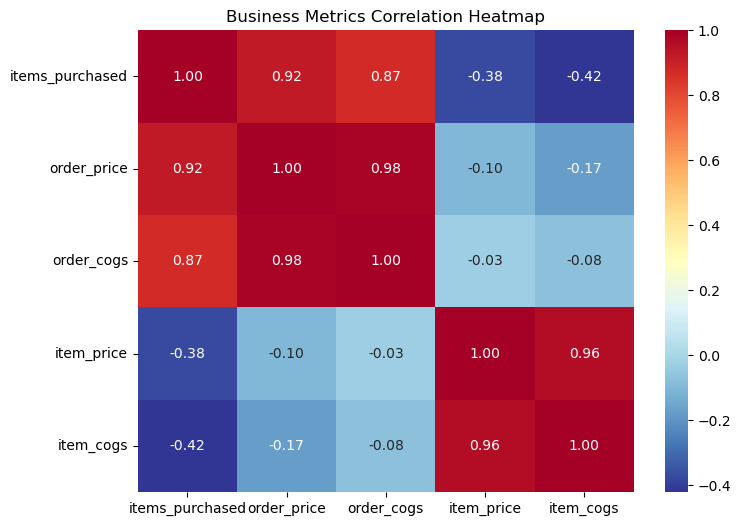

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f'
)

plt.title('Business Metrics Correlation Heatmap')
plt.show()

### Key Insight

Items Purchased and Order Price show a strong positive correlation (0.92), indicating that larger basket sizes directly increase revenue. Additionally, Item Price and Item Cost are highly correlated (0.96), reflecting a consistent pricing structure. The negative relationship between Items Purchased and Item Price suggests that customers are more likely to buy multiple items when products are affordably priced. Therefore, bundle promotions and cross-selling strategies could significantly boost overall revenue.

# Conclusion

This project analyzed the sales, customer behavior, website traffic, product performance, conversion rates, and refund patterns of the Fuzzy Factory e-commerce business.

The analysis revealed that revenue and sales performance are strongly influenced by product popularity, website traffic sources, and customer purchasing behavior. By combining website session data with order and product information, valuable insights were generated to support data-driven business decisions.

# Key Findings

### 1. Revenue Trend
- Revenue showed strong growth toward the end of the year.
- November and December generated the highest revenue, indicating seasonal demand.

### 2. Product Performance
- The Original Mr. Fuzzy was the best-selling product.
- It significantly outperformed all other products in terms of orders and revenue.

### 3. Customer Behavior
- 83% of website visitors were new visitors.
- Only 17% were repeat visitors, highlighting an opportunity to improve customer retention.

### 4. Traffic Source Performance
- Gsearch generated the highest volume of website sessions and orders.
- Search-based marketing channels were the primary drivers of customer acquisition.

### 5. Conversion Performance
- Website traffic converted effectively into sales.
- Product performance varied significantly, with some products contributing much more strongly to conversions.

### 6. Refund Analysis
- Refund patterns varied across products.
- Monitoring refund trends can help identify product quality or customer satisfaction issues.

# Business Recommendations

### Increase Customer Retention
- Implement loyalty programs.
- Launch personalized email campaigns.
- Offer incentives for repeat purchases.

### Reduce Product Dependency
- Promote lower-performing products through targeted campaigns.
- Introduce product bundles and cross-selling opportunities.

### Optimize Marketing Spend
- Continue investing in high-performing traffic sources.
- Regularly evaluate conversion performance across channels.

### Increase Average Order Value
- Implement bundle discounts.
- Recommend complementary products during checkout.

# Future Scope

Future analysis can be enhanced by:

- Customer segmentation analysis.
- Predictive sales forecasting.
- Customer lifetime value (CLV) modeling.
- Product recommendation systems.
- Marketing campaign ROI optimization.

# Final Remark

The analysis demonstrates how data can be transformed into actionable business insights. The findings can help Fuzzy Factory improve customer acquisition, increase retention, optimize product strategy, and drive sustainable revenue growth.